# Student Performace Indicator
### Life cycle of Machine Learning Project

- Understanding the problem Statement
- Data Collection
- Data Checks to Perform
- Explratory Data Analysis
- Data Pre-Processing
- Model Training
- Choose Best Model

## 1. Problem Statement

- This Project understands how the student's performance (test scores) is affected by other variables such as Gender, Ethnicity, Parental Level of Education, Lunch and Test Preperation Course.

## 2. Data Collection

- Dataset Source - 
- The data consists of 8 columns and 1000 rows

In [41]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [42]:
df = pd.read_csv('data/students_data.csv')

In [43]:
df.head()

,Gender,Race_Ethnicity,Parental_Education,Lunch,Test_Preparation_Course,Math_Score,Reading_Score,Writing_Score
0,Male,Group C,Associate's Degree,Free,Not Completed,58,58,61
1,Female,Group C,Some College,Paid,Not Completed,40,43,95
2,Male,Group C,College,Paid,Completed,88,85,58
3,Male,Group D,Master's Degree,Paid,Not Completed,99,42,45
4,Male,Group D,Some College,Paid,Not Completed,87,67,97


## 2.2 Dataset Information

- gender: sex of Student -> (Male/Female)
- race/ethnicity: ethnicity of studetns -> (Group A, B, C, D, E)
- parental level of education: parent's final education -> (bachleor's degree, some college, master's degree, associate's degree, high school)
- lunch: having lunch before test (standard or free/reduced)
- test preperation course: complete or not complete before test
- maths score
- reading score
- writing score

## 3 Data Checks to Perform

- Check missing values
- Check Duplicates
- Check Data Type
- Check the number of unique values of each column
- Check Statistics of dataset
- Check various categories present in the different categorical column

## 3.1 Check for missing values

In [44]:
df.isna().sum()

Gender                     0
Race_Ethnicity             0
Parental_Education         0
Lunch                      0
Test_Preparation_Course    0
Math_Score                 0
Reading_Score              0
Writing_Score              0
dtype: int64

In [45]:
df.duplicated().sum()

np.int64(0)

In [46]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Gender                   1000 non-null   str  
 1   Race_Ethnicity           1000 non-null   str  
 2   Parental_Education       1000 non-null   str  
 3   Lunch                    1000 non-null   str  
 4   Test_Preparation_Course  1000 non-null   str  
 5   Math_Score               1000 non-null   int64
 6   Reading_Score            1000 non-null   int64
 7   Writing_Score            1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


## Checking the number of unique values in each column

In [47]:
df.nunique()

Gender                      2
Race_Ethnicity              5
Parental_Education          5
Lunch                       2
Test_Preparation_Course     2
Math_Score                 61
Reading_Score              61
Writing_Score              61
dtype: int64

In [48]:
df.describe()

,Math_Score,Reading_Score,Writing_Score
count,1000.000000,1000.000000,1000.00000
mean,69.706000,70.076000,70.32700
std,17.914365,17.664605,17.64555
min,40.000000,40.000000,40.00000
25%,54.000000,55.000000,56.00000
50%,69.000000,70.000000,70.00000
75%,85.250000,86.000000,86.00000
max,100.000000,100.000000,100.00000


## Insights

- from above description of numerical data, all means are very close to each otehr
- All Standard deviation are also very close to each other

## Exploring Data


In [49]:
df.head()

,Gender,Race_Ethnicity,Parental_Education,Lunch,Test_Preparation_Course,Math_Score,Reading_Score,Writing_Score
0,Male,Group C,Associate's Degree,Free,Not Completed,58,58,61
1,Female,Group C,Some College,Paid,Not Completed,40,43,95
2,Male,Group C,College,Paid,Completed,88,85,58
3,Male,Group D,Master's Degree,Paid,Not Completed,99,42,45
4,Male,Group D,Some College,Paid,Not Completed,87,67,97


In [50]:
print("Categories in 'Gender' variable:    ", end=" ")
print(df['Gender'].unique())

print("Catogeries in 'Race_Ethnicity' variable:   ", end=" ")
print(df['Race_Ethnicity'].unique())

print("Catogeries in 'parental level of education' variable:   ", end=" ")
print(df['Parental_Education'].unique())

print("Catogeries in 'lunch' variable:   ", end=" ")
print(df['Lunch'].unique())

print("Catogeries in 'test preperation course' variable:   ", end=" ")
print(df['Test_Preparation_Course'].unique())


Categories in 'Gender' variable:     <StringArray>
['Male', 'Female']
Length: 2, dtype: str
Catogeries in 'Race_Ethnicity' variable:    <StringArray>
['Group C', 'Group D', 'Group B', 'Group A', 'Group E']
Length: 5, dtype: str
Catogeries in 'parental level of education' variable:    <StringArray>
['Associate's Degree',       'Some College',            'College',
    'Master's Degree',        'High School']
Length: 5, dtype: str
Catogeries in 'lunch' variable:    <StringArray>
['Free', 'Paid']
Length: 2, dtype: str
Catogeries in 'test preperation course' variable:    <StringArray>
['Not Completed', 'Completed']
Length: 2, dtype: str


In [53]:
# define numerical & cateogical columns
numeric_features = [feature for feature in df.columns if df[feature].dtype == 'int64' ]
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'str']

# print columns
print("we have {} numerical features: {}".format(len(numeric_features), numeric_features))
print("we have {} categorical features: {}".format(len(categorical_features), categorical_features))

we have 3 numerical features: ['Math_Score', 'Reading_Score', 'Writing_Score']
we have 5 categorical features: ['Gender', 'Race_Ethnicity', 'Parental_Education', 'Lunch', 'Test_Preparation_Course']


## Adding Columns for "Total Score"  and "Average Score"

In [54]:
df['total_score'] = df['Math_Score'] + df['Reading_Score'] + df['Writing_Score']
df['average'] = df['total_score'] / 3
df.head()

,Gender,Race_Ethnicity,Parental_Education,Lunch,Test_Preparation_Course,Math_Score,Reading_Score,Writing_Score,total_score,average
0,Male,Group C,Associate's Degree,Free,Not Completed,58,58,61,177,59.000000
1,Female,Group C,Some College,Paid,Not Completed,40,43,95,178,59.333333
2,Male,Group C,College,Paid,Completed,88,85,58,231,77.000000
3,Male,Group D,Master's Degree,Paid,Not Completed,99,42,45,186,62.000000
4,Male,Group D,Some College,Paid,Not Completed,87,67,97,251,83.666667


In [55]:
reading_full = df[df['Reading_Score'] == 100]['average'].count()
writing_full = df[df['Writing_Score'] == 100]['average'].count()
math_full = df[df['Math_Score'] == 100]['average'].count()

print("Students with full reading marks: ", reading_full)
print("Students with full writing marks: ", writing_full)
print("Students with full math marks: ", math_full)

Students with full reading marks:  25
Students with full writing marks:  10
Students with full math marks:  11


## Histogram and KDE

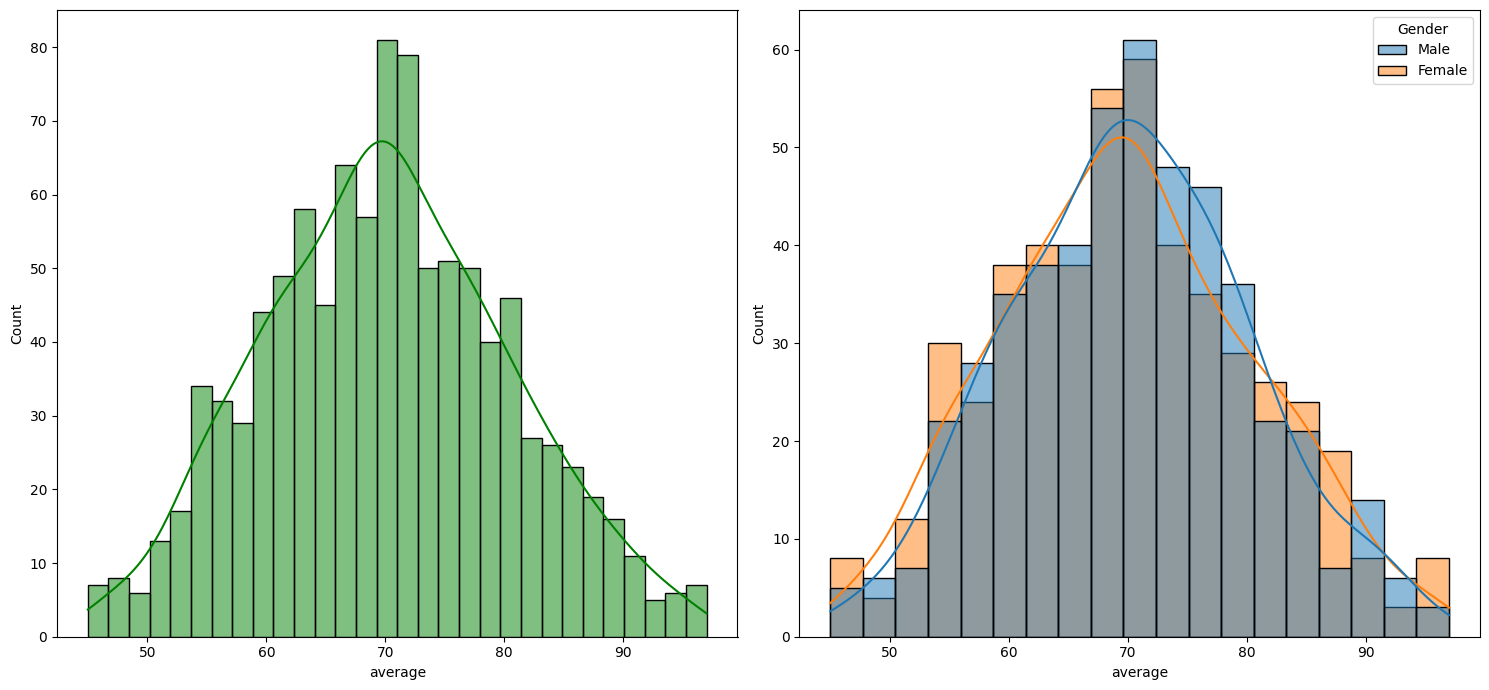

In [60]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7))

sns.histplot(data=df, x='average', bins=30, kde=True, color='g', ax=axs[0])

sns.histplot(data=df, x='average', kde=True, hue='Gender', ax=axs[1])

plt.tight_layout()
plt.show()